## 1. Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline


## 2. Load the Dataset



In [6]:
car = pd.read_csv('quikr_car.csv')
print(car.shape)
car.head()


(892, 6)


,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [7]:
car.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


## 3. Understand the Mess


In [8]:
print("Unique years (sample):", car['year'].unique()[:15])
print()
print("Unique fuel types:", car['fuel_type'].unique())
print()
print("Sample kms_driven values:", car['kms_driven'].unique()[:10])
print()
print("Missing values:\n", car.isnull().sum())


Unique years (sample): ['2007' '2006' '2018' '2014' '2015' '2012' '2013' '2016' '2010' '2017'
 '2008' '2011' '2019' '2009' '2005']

Unique fuel types: ['Petrol' 'Diesel' nan 'LPG']

Sample kms_driven values: ['45,000 kms' '40 kms' '22,000 kms' '28,000 kms' '36,000 kms' '59,000 kms'
 '41,000 kms' '25,000 kms' '24,530 kms' '60,000 kms']

Missing values:
 name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64


## 4. Clean the Data

In [9]:
car_clean = car.copy()

# --- year: keep only rows where year is a 4-digit number ---
car_clean = car_clean[car_clean['year'].str.isnumeric()]
car_clean['year'] = car_clean['year'].astype(int)

# --- Price: remove 'Ask For Price' rows, remove commas, convert to int ---
car_clean = car_clean[car_clean['Price'] != 'Ask For Price']
car_clean['Price'] = car_clean['Price'].str.replace(',', '').astype(int)

# --- kms_driven: remove 'kms' text and commas, drop rows where it's not numeric (misaligned data) ---
car_clean['kms_driven'] = car_clean['kms_driven'].str.replace(' kms', '', regex=False)
car_clean['kms_driven'] = car_clean['kms_driven'].str.replace(',', '', regex=False)
car_clean = car_clean[car_clean['kms_driven'].str.isnumeric()]
car_clean['kms_driven'] = car_clean['kms_driven'].astype(int)

# --- fuel_type: drop missing values ---
car_clean = car_clean[~car_clean['fuel_type'].isna()]

# --- name: keep first 3 words only (e.g. 'Hyundai Santro Xing' instead of full trim/variant) ---
car_clean['name'] = car_clean['name'].str.split(' ').str.slice(0, 3).str.join(' ')

# --- remove extreme price outliers (helps the model a lot) ---
car_clean = car_clean[car_clean['Price'] < 6_000_000]

# --- reset index ---
car_clean = car_clean.reset_index(drop=True)

print("Rows before cleaning:", car.shape[0])
print("Rows after cleaning:", car_clean.shape[0])
car_clean.head()


Rows before cleaning: 892
Rows after cleaning: 815


,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel


In [10]:
car_clean.describe(include='all')


,name,company,year,Price,kms_driven,fuel_type
count,815,815,815.000000,8.150000e+02,815.000000,815
unique,254,25,NaN,NaN,NaN,3
top,Maruti Suzuki Swift,Maruti,NaN,NaN,NaN,Petrol
freq,51,221,NaN,NaN,NaN,428
mean,NaN,NaN,2012.442945,4.017933e+05,46277.096933,NaN
std,NaN,NaN,4.005079,3.815888e+05,34318.459638,NaN
min,NaN,NaN,1995.000000,3.000000e+04,0.000000,NaN
25%,NaN,NaN,2010.000000,1.750000e+05,27000.000000,NaN
50%,NaN,NaN,2013.000000,2.999990e+05,41000.000000,NaN
75%,NaN,NaN,2015.000000,4.900000e+05,56879.000000,NaN


## 5. Save the Cleaned Dataset



In [11]:
car_clean.to_csv('cleaned_car_data.csv', index=False)
print("Saved cleaned_car_data.csv")

# In Colab, download it with:
# from google.colab import files
# files.download('cleaned_car_data.csv')


Saved cleaned_car_data.csv


## 6. Exploratory Data Analysis (EDA)

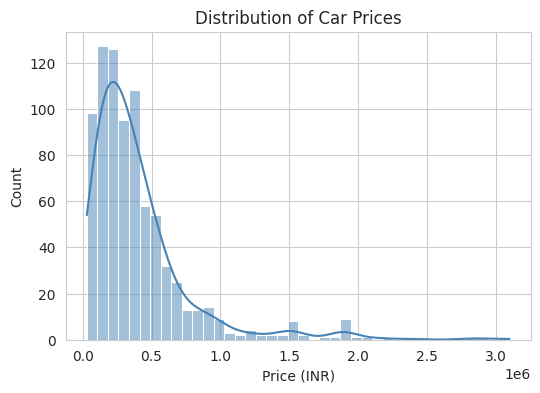

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(car_clean['Price'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price (INR)')
plt.show()


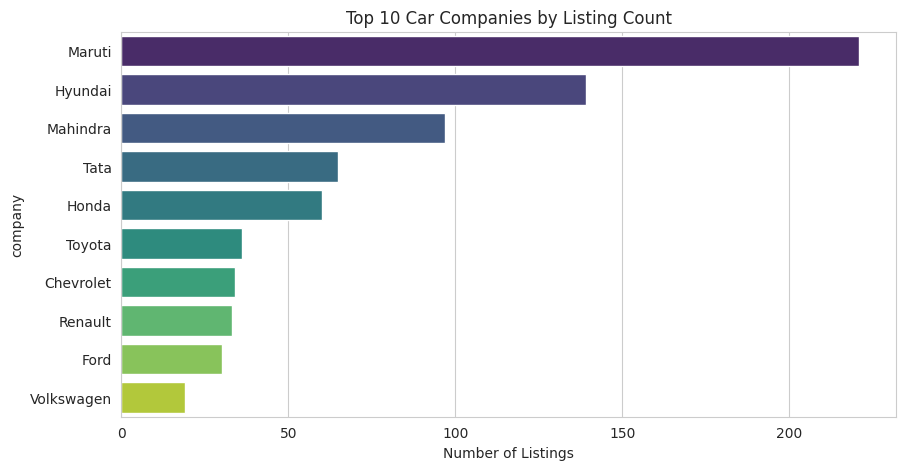

In [13]:
plt.figure(figsize=(10,5))
top_companies = car_clean['company'].value_counts().head(10)
sns.barplot(x=top_companies.values, y=top_companies.index, palette='viridis')
plt.title('Top 10 Car Companies by Listing Count')
plt.xlabel('Number of Listings')
plt.show()


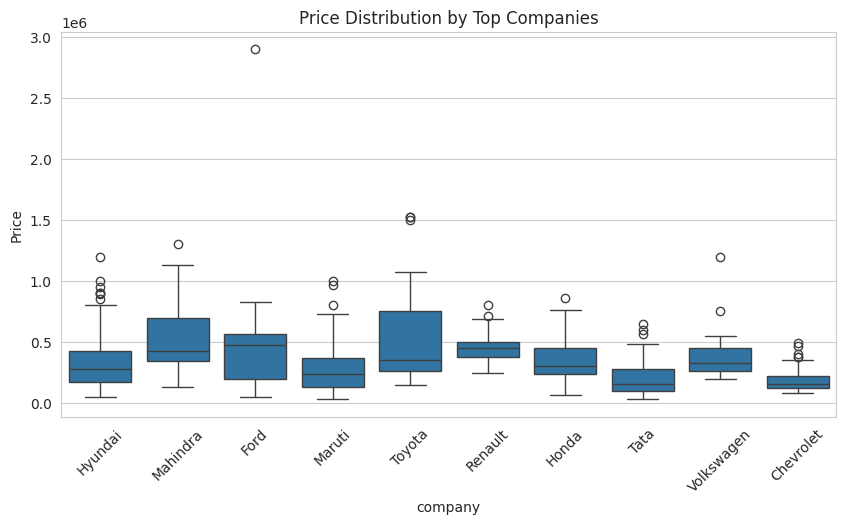

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(x='company', y='Price',
            data=car_clean[car_clean['company'].isin(top_companies.index)])
plt.xticks(rotation=45)
plt.title('Price Distribution by Top Companies')
plt.show()


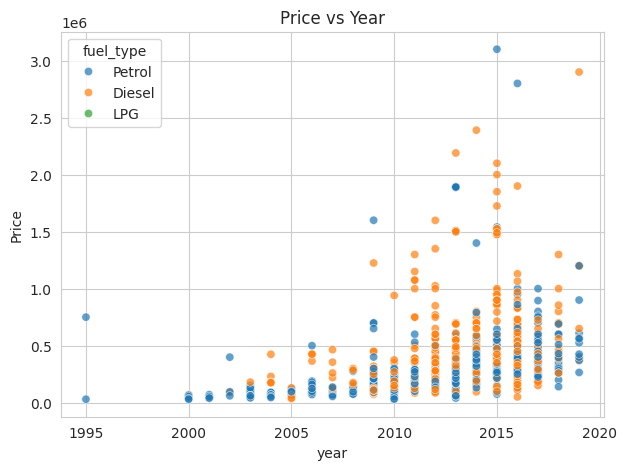

In [15]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='year', y='Price', data=car_clean, hue='fuel_type', alpha=0.7)
plt.title('Price vs Year')
plt.show()


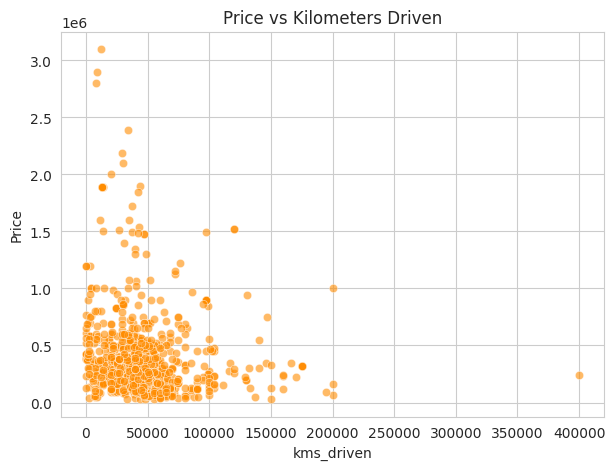

In [16]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='kms_driven', y='Price', data=car_clean, alpha=0.6, color='darkorange')
plt.title('Price vs Kilometers Driven')
plt.show()


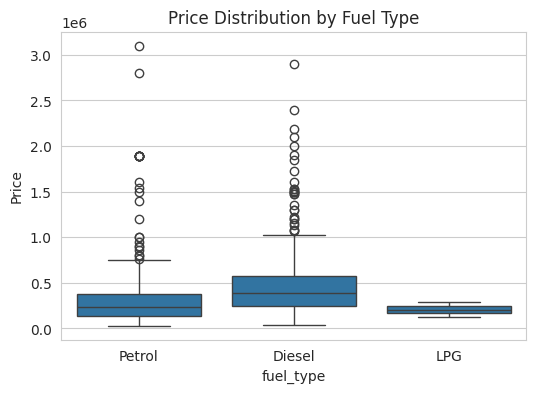

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x='fuel_type', y='Price', data=car_clean)
plt.title('Price Distribution by Fuel Type')
plt.show()


## 7. Prepare Data for Modeling


In [18]:
X = car_clean[['name', 'company', 'year', 'kms_driven', 'fuel_type']]
y = car_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 652 | Test size: 163


## 8. Build a Preprocessing + Model Pipeline

In [19]:
ohe = OneHotEncoder(handle_unknown='ignore')

column_trans = make_column_transformer(
    (ohe, ['name', 'company', 'fuel_type']),
    remainder='passthrough'
)

model = LinearRegression()

pipe = make_pipeline(column_trans, model)
pipe.fit(X_train, y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('linearregression', LinearRegression())])

## 9. Evaluate the Model

In [20]:
y_pred = pipe.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error: ₹{mae:,.0f}")


R² Score: 0.573
Mean Absolute Error: ₹148,116


In [21]:
# Find the best random_state for the train/test split (common trick with this dataset)
scores = []
for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    scores.append(r2_score(y_test, y_pred))

best_i = int(np.argmax(scores))
print(f"Best random_state: {best_i}, R² Score: {scores[best_i]:.3f}")


Best random_state: 433, R² Score: 0.846


In [22]:
# Retrain the final model using the best split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=best_i)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(f"Final R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"Final MAE: ₹{mean_absolute_error(y_test, y_pred):,.0f}")


Final R² Score: 0.846
Final MAE: ₹108,493


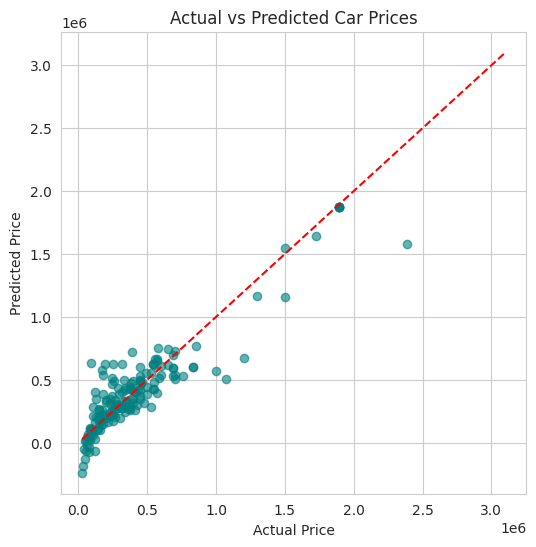

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.show()


## 10. Predict Price for a New Car



In [24]:
sample = pd.DataFrame(
    [['Maruti Suzuki Swift', 'Maruti', 2019, 25000, 'Petrol']],
    columns=['name', 'company', 'year', 'kms_driven', 'fuel_type']
)

predicted_price = pipe.predict(sample)
print(f"Predicted Price: ₹{predicted_price[0]:,.0f}")


Predicted Price: ₹447,935


## 11. Save the Trained Model



In [25]:
import pickle

with open('car_price_predictor_model.pkl', 'wb') as f:
    pickle.dump(pipe, f)

print("Model saved as car_price_predictor_model.pkl")

# In Colab, download it with:
# from google.colab import files
# files.download('car_price_predictor_model.pkl')


Model saved as car_price_predictor_model.pkl
